#  Classification ML Project using Logistic Regression

Using the Indian Liver Disease dataset, we would like to develop a logistic regression machine learning model where the output variable of interest would be a binary response variable labelled 'Selector'. This column contains records of 416 patients diagnosed with liver disease and 167 patients without liver disease. 

There are 10 variables per patient: age, gender, total Bilirubin, direct Bilirubin, total proteins, albumin, A/G ratio, SGPT, SGOT and Alkphos. Of the 583 patient records, 441 are male, and 142 are female.

## Clinical variables

Below is a brief description of each clinical variable and how it helps predict liver disease;

- **Bilirubin** is a yellowish pigment formed during the breakdown of hemoglobin in red blood cells. It is processed in the liver and excreted in bile. There are two types of bilirubin that are clinically significant in predicting the presence of liver disease; **Total Bilirum (TB)** and **Direct Bilirubin (DB)**. Total bilirubin is the sum of direct bilirubin (conjugated) and indirect bilirubin (unconjugated) in the blood. Direct bilirubin (conjugated) is bilirubin that has been processed by the liver, becoming water-soluble whereas Indirect bilirubin (unconjugated) has not yet been processed by the liver and is not water-soluble. The normal range is approximately 0.3 to 1.2 mg/dL in adults. Elevated levels of bilirubin, especially direct bilirubin, are significant markers for liver dysfunction and biliary system issues.

- **Alkaline Phosphotase (Alkphos)** is an enzyme found in several tissues throughout the body, with the highest concentrations in the liver, bones, kidneys and biliary tract. It plays an important role in breaking down proteins and is most active in alkaline conditions. The normal range in adults is 44 to 147 IU/L. Elevated levels are often associated with conditions affecting the liver, bile ducts, or bones.

- **Alanine Aminotransferase (Sgpt)** and **Aspartate Aminotransferase (Sgot)** are enzymes found in various tissues of the body, but they are most abundant in the liver. They play a role in amino acid metabolism, helping convert amino acids into energy or other compounds. 

Alanine Aminotransferase is predominantly found in liver cells (hepatocytes), with smaller amounts in muscles and kidneys. It converts alanine and alpha-ketoglutarate into pyruvate and glutamate. The normal range for adults is ~7 to 56 units per liter (U/L). When liver cells are damaged or inflamed, it leaks into the bloodstream, making it a sensitive marker for liver injury. 

Aspartate Aminotransferase is predominantly found in liver cells (hepatocytes), with smaller amounts in muscles and kidneys. It catalyzes the conversion of aspartate and alpha-ketoglutarate to oxaloacetate and glutamate. The normal range for adults is ~10 to 40 units per liter (U/L). When elevated, it can indicate muscle injury or heart disease.

- **Total Proteins (TP)** refers to the total concentration of proteins in the blood, primarily consisting of:
1. ***Albumin***: A protein produced by the liver, crucial for maintaining oncotic pressure (fluid balance) and transporting substances like hormones and drugs.
2. ***Globulins***: A group of proteins involved in immune functions, blood clotting, and transportation.

The normal range in adults is 6.0 to 8.3 g/dL. Low Total Protein (Hypoproteinemia) may indicate the presence of chronic liver disease, malnutrition or increased protein loss whereas High Total Protein (Hyperproteinemia) could be an indicator of dehydration chronic infections or inflammation. 

**Albumin-to-Globulin (A/G) Ratio** is total protein and liver disease marker that should range between ~1.2 to 1.5. A low ratio (<1) may indicate presence of chronic liver disease, where albumin synthesis is impaired and globulins increase. A high ratio (>1.5) may indicate dehydration and certain congenital conditions

## Objectives

The objective of this project is to build a logistic regression model to predict whether a patient has liver disease based on several medical features. Specifically, the goal is to:
1. Understand the relationship between medical variables (such as age, gender, liver enzyme levels, etc.) and the likelihood of a patient having liver disease.
2. Develop a predictive model that can **classify** patients into two categories: those who have liver disease and those who do not.
3. Evaluate model performance by using key metrics like accuracy, precision, recall, F1-score, and the confusion matrix, which will help determine how well the model predicts liver disease outcomes.
4. Explore the impact of various medical markers (e.g., Alanine Aminotransferase, Aspartate Aminotransferase, Total Bilirubin) on liver health, helping to identify which variables are most influential in predicting liver disease.

## Import Libraries

In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Dataset

In [106]:
## Load the dataset
file_path = "C:/Users/Analytics/OneDrive - Africa Healthcare Network/Desktop/python_ws/Indian Liver Patient Dataset (ILPD).csv"  # Update this path to your file location
data = pd.read_csv(file_path)

### Exploring the data

In [107]:
## Viewing the first few rows
data.head()

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [108]:
## Summary statistics of the data
data.describe()

,Age,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
count,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,579.000000,583.000000
mean,44.746141,3.298799,1.486106,290.576329,80.713551,109.910806,6.483190,3.141852,0.947064,1.286449
std,16.189833,6.209522,2.808498,242.937989,182.620356,288.918529,1.085451,0.795519,0.319592,0.452490
min,4.000000,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000,1.000000
25%,33.000000,0.800000,0.200000,175.500000,23.000000,25.000000,5.800000,2.600000,0.700000,1.000000
50%,45.000000,1.000000,0.300000,208.000000,35.000000,42.000000,6.600000,3.100000,0.930000,1.000000
75%,58.000000,2.600000,1.300000,298.000000,60.500000,87.000000,7.200000,3.800000,1.100000,2.000000
max,90.000000,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000,2.000000


In [109]:
## Checking for missing values
print(data.isnull().sum())

Age          0
Gender       0
TB           0
DB           0
Alkphos      0
Sgpt         0
Sgot         0
TP           0
ALB          0
A/G Ratio    4
Selector     0
dtype: int64


In [110]:
## Replace missing values using the mean() method
data.fillna({'A/G Ratio': data['A/G Ratio'].mean()}, inplace=True)
data.isnull().sum()

Age          0
Gender       0
TB           0
DB           0
Alkphos      0
Sgpt         0
Sgot         0
TP           0
ALB          0
A/G Ratio    0
Selector     0
dtype: int64

In [111]:
# Convert 'Gender' column to numeric (1 for Male, 0 for Female)
data['Gender'] = data['Gender'].map({'Male': 1, 'Female': 0})
data['Selector'] = data['Selector'].map({1: 0, 2: 1})

## Model Creation

In [112]:
X = data.drop(['Selector', 'DB'], axis=1)  # Input variables
y = data['Selector']  # Target variable

In [113]:
# Normalize the feature data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Spliting the data

In [114]:
#Split the data into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

### Logistic Regression Model

In [115]:
#Create the Logistic Regression model
model = LogisticRegression(max_iter=1000)  # You can adjust max_iter based on convergence
model.fit(X_train, y_train)

#Make predictions using the test set
y_pred = model.predict(X_test)

## Evaluate the model

In [116]:
# Accuracy Score
# Shows the percentage of correct predictions.
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 76.07%


In [117]:
# Confusion Matrix
# A matrix showing the true positives, false positives, true negatives, and false negatives.
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:')
print(cm)

Confusion Matrix:
[[81  6]
 [22  8]]


In [118]:
# Classification Report
# Provides a detailed performance evaluation with precision, recall, and F1-score.
print('Classification Report:')
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.93      0.85        87
           1       0.57      0.27      0.36        30

    accuracy                           0.76       117
   macro avg       0.68      0.60      0.61       117
weighted avg       0.73      0.76      0.73       117



### Visualizing the confusion matrix

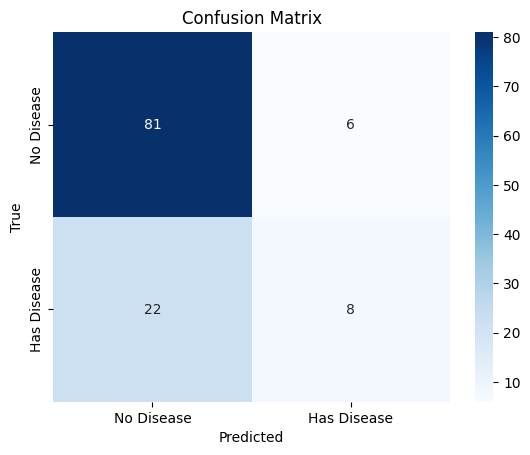

In [119]:
# Optional: Visualize the confusion matrix with a heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Disease', 'Has Disease'], yticklabels=['No Disease', 'Has Disease'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

## Interpretation of results

- **Precision (0.57)**: 57% of the cases predicted as having liver disease are correct. This indicates a moderate level of confidence in the model's positive predictions. However, 43% of the positive predictions are false positives, which could be concerning in medical diagnosis as it might lead to unnecessary follow-ups or treatments.
- **Recall (0.27)**: The model correctly identified only 27% of actual liver disease cases. This low recall suggests that the model misses a large proportion of patients who actually have liver disease (high false negatives). In medical applications, this is a significant limitation because failing to detect a disease can lead to severe consequences.
- **F1-Score (0.36)**: The F1-score is a balance between precision and recall, and at 0.36, it reflects poor overall performance for the positive class (patients with liver disease). It confirms that the model struggles to both identify and correctly classify liver disease cases.

### What next?

1. **Address Class Imbalance**: If the dataset has more "No Disease" cases than "Has Disease," try techniques like: Oversampling the minority class (e.g., using SMOTE), undersampling the majority class and/or applying class weights in the logistic regression model (class_weight='balanced').
2. **Feature Engineering**: Reassess the input features. Are there important variables missing? Could you derive new features that better explain the variability in the target?
3. **Model Optimization**: Try other classification algorithms (e.g., Random Forest, Gradient Boosting, or Support Vector Machines) to compare performance. Tune hyperparameters, such as the C parameter in logistic regression, to improve the model's fit.
4. **Focus on Recall**: In medical diagnostics, prioritize recall to reduce false negatives (i.e., missed disease cases). Adjust the decision threshold to improve recall, even if precision slightly decreases.

## Improving the model through oversampling the minority class

We shall use the Synthetic Minority Over-Sampling Technique (SMOTE) from the **imbleran** library to generate synthetic samples for the minority class.

In [120]:
## Oversampling the minority class
from imblearn.over_sampling import SMOTE
smote = SMOTE()
X_resampled, y_resampled = smote.fit_resample(X, y)

Use the same steps as before to create and evaluate the new model

In [121]:
# Normalize the feature data
scaler = StandardScaler()
X_scaled_v1 = scaler.fit_transform(X_resampled)

In [122]:
#Split the data into training and test sets (80% train, 20% test)
X_train_v1, X_test_v1, y_train_v1, y_test_v1 = train_test_split(X_scaled_v1, y_resampled, test_size=0.2, random_state=42)

In [123]:
#Create the Logistic Regression model
model = LogisticRegression(max_iter=1000)  # You can adjust max_iter based on convergence
model.fit(X_train_v1, y_train_v1)

#Make predictions using the test set
y_pred_v1 = model.predict(X_test_v1)

In [124]:
# Accuracy Score
# Shows the percentage of correct predictions.
accuracy = accuracy_score(y_test_v1, y_pred_v1)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 76.65%


In [125]:
# Confusion Matrix
# A matrix showing the true positives, false positives, true negatives, and false negatives.
cm_smote = confusion_matrix(y_test_v1, y_pred_v1)
print('Confusion Matrix:')
print(cm_smote)

Confusion Matrix:
[[49 26]
 [13 79]]


In [126]:
# Classification Report
# Provides a detailed performance evaluation with precision, recall, and F1-score.
print('Classification Report:')
print(classification_report(y_test_v1, y_pred_v1))

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.65      0.72        75
           1       0.75      0.86      0.80        92

    accuracy                           0.77       167
   macro avg       0.77      0.76      0.76       167
weighted avg       0.77      0.77      0.76       167



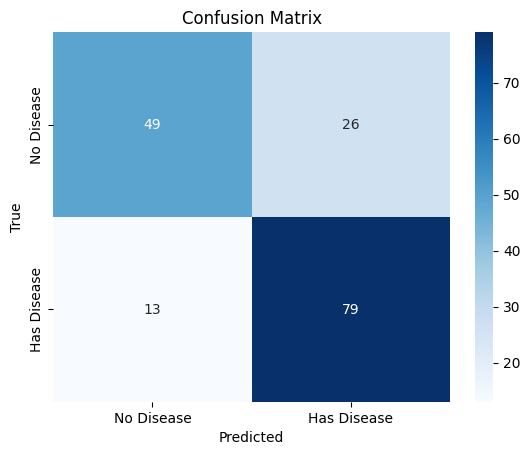

In [127]:
# Optional: Visualize the confusion matrix with a heatmap
sns.heatmap(cm_smote, annot=True, fmt='d', cmap='Blues', xticklabels=['No Disease', 'Has Disease'], yticklabels=['No Disease', 'Has Disease'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

### Interpetation of results

- **Precision (0.75)**: 75% of the cases predicted as having liver disease are correct. This indicates a good balance between true positives and false positives. The model is less likely to wrongly classify patients without liver disease as having it, which minimizes unnecessary medical interventions.
- **Recall (0.86)**: The model correctly identified only 86% of actual liver disease cases. This recall is a significant improvement from the earlier recall of 0.27. A high recall is critical in medical diagnosis since it reduces the number of missed disease cases (false negatives). 
- **F1-Score (0.80)**: The F1-score is a balance between precision and recall, and at 0.80, it confirms that the model performs well in detecting liver disease cases without a significant trade-off between false positives and false negatives.
- **Accuracy (0.77)**: The model correctly predicts 77% of all cases (both disease and non-disease). While this metric aligns with your earlier results, it is now less misleading because of the balanced precision and recall.

### Conclusion

The analysis demonstrates a significant improvement in the model's ability to predict liver disease cases accurately, particularly after addressing the dataset imbalance using SMOTE. The final metrics—precision (0.75), recall (0.86), F1-score (0.80), and accuracy (0.77)—indicate a well-performing and balanced model.

Key Insights:

The model achieves a high recall, correctly identifying 86% of patients with liver disease, which is crucial for minimizing missed cases in a medical context.
The precision of 75% ensures that most patients flagged as having liver disease are indeed true positives, reducing the risk of unnecessary treatments.
Stakeholder Impact:

The model is suitable for medical applications where the goal is to maximize recall without sacrificing precision significantly.
It can assist healthcare professionals in early diagnosis and intervention, potentially improving patient outcomes.